### 数据集

In [388]:
import numpy as np
import matplotlib.pyplot as plt

In [389]:
w, b = 1.8, 2.5  # 设置真实的权重 w 和偏置 b，用于生成模拟数据

In [390]:
np.random.seed(0)

In [391]:
X = np.random.rand(100) * 4 - 2   # 随机生成 100 个 x，取值范围约为 [-2, 2)
noise = np.random.randn(100) / 3  # 生成随机噪声，使数据更接近真实情况

In [392]:
y = w * X + b + noise  # 根据线性关系 y = wx + b，并加入噪声生成目标值 y

In [393]:
X = X.reshape(-1, 1)

In [394]:
X.shape, y.shape

((100, 1), (100,))

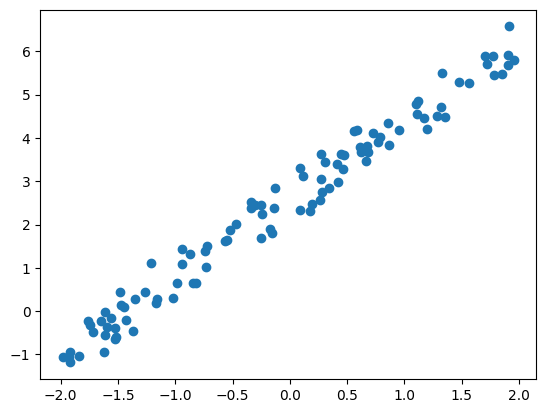

In [395]:
plt.scatter(X, y)
plt.show()

### sklearn中的神经网络

In [396]:
from sklearn.neural_network import MLPRegressor

In [397]:
reg = MLPRegressor(
    hidden_layer_sizes=(1,),  # 设置 1 个隐藏层，隐藏层中包含 1 个神经元
    activation="identity",    # 使用线性激活函数 f(x)=x
    learning_rate_init=0.01,  # 设置初始学习率
    random_state=233)

In [398]:
reg.fit(X, y);

In [399]:
reg.score(X, y)

0.974674992013746

In [400]:
y_pred = reg.predict(X)

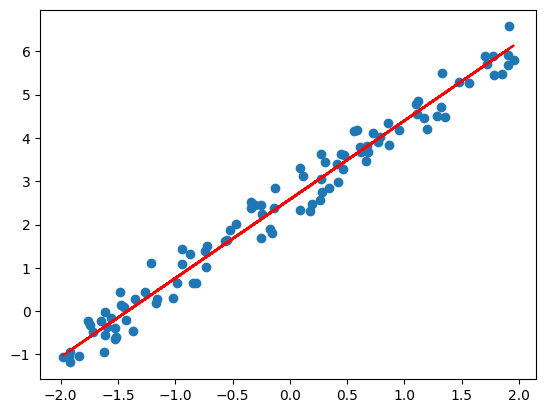

In [401]:
plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.show()

In [402]:
reg.coefs_  # 查看神经网络各层之间学习到的权重

[array([[-2.02307729]]), array([[-0.89941477]])]

In [403]:
reg.intercepts_  # 查看神经网络各层学习到的偏置

[array([0.20843202]), array([2.76734195])]

In [404]:
w1, w2 = np.array(reg.coefs_).reshape(-1)  # 将各层的权重展开，并分别取出 w1、w2
b1, b2 = np.array(reg.intercepts_).reshape(-1)  # 将各层的偏置展开，并分别取出 b1、b2

In [405]:
# 计算整个神经网络等价线性模型的权重和偏置，所以可以看到，神经网络通过训练基本学回了原始数据中的 w=1.8 和 b=2.5。
w1 * w2, w2 * b1 + b2

(np.float64(1.8195855887612917), np.float64(2.5798751106877256))

### 手动实现反向传播权重更新

In [406]:
w1, b1, w2, b2 = np.random.rand(4)  # 随机初始化两层网络的权重和偏置
w1, b1, w2, b2

(np.float64(0.2074700754411094),
 np.float64(0.42468546875150626),
 np.float64(0.37416998033422555),
 np.float64(0.4635754243648107))

In [407]:
y_real = y.reshape(-1,1)
lr = 0.01  # 设置学习率

In [408]:
for i in range(1000):      # 迭代 1000 次，通过反向传播更新参数
    y1 = w1 * X + b1       # 隐藏层：线性计算
    y_pred = w2 * y1 + b2  # 输出层：得到最终预测值
    loss = ((y_real - y_pred) ** 2) / 2  # 计算平方误差损失

    dy = y_pred - y_real  # 计算损失对预测值的梯度
    dy1 = dy * w2         # 将梯度从输出层反向传播到隐藏层

    dw1 = np.mean(X * dy1)  # w1 的梯度
    dw2 = np.mean(y1 * dy)  # w2 的梯度
    db1 = np.mean(dy1)      # b1 的梯度
    db2 = np.mean(dy)       # b2 的梯度

    w1 -= lr * dw1
    w2 -= lr * dw2
    b1 -= lr * db1
    b2 -= lr * db2

print(w1, b1, w2, b2)

1.19866012053512 0.9425245513340756 1.4972923136173089 1.1523047632746386


In [409]:
w1 * w2, w2 * b1 + b2

(np.float64(1.794744585116832), np.float64(2.5635395293827528))

In [410]:
y_pred = w2 * (w1 * X + b1) + b2  # 使用训练完成后的参数计算最终预测结果

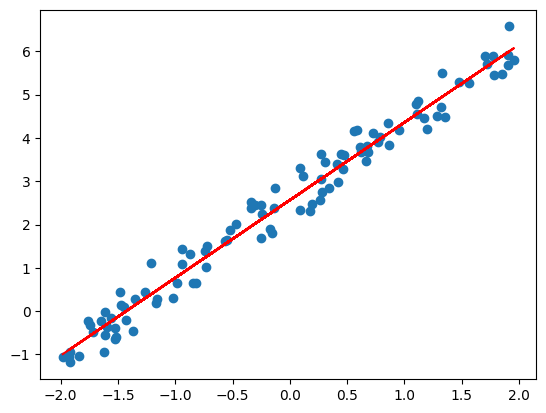

In [411]:
plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.show()